# 프로젝트: CAM을 만들고 평가해 보자

## 1. 라이브러리

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch.nn.functional as F

import xml.etree.ElementTree as ET
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## 2. 데이터셋 가져오기

In [2]:
class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    def __init__(self, root, annotation_root, transform=None):
        super().__init__(root, transform=transform)
        self.annotation_root = annotation_root  # 예: '/content/Annotation'
        self.new_size = (224, 224)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]

        rel_path = os.path.relpath(path, self.root)
        annot_filename = os.path.splitext(os.path.basename(rel_path))[0]
        annot_folder = os.path.dirname(rel_path)
        annot_path = os.path.join(self.annotation_root, annot_folder, annot_filename)

        # bbox 기본값 (예: [ymin, xmin, ymax, xmax])
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(annot_path):
            try:
                # 확장자가 없지만 XML 형식의 파일이라고 가정하고 파싱
                tree = ET.parse(annot_path)
                root_xml = tree.getroot()
                # 첫 번째 object 태그에서 bndbox 정보를 읽음
                obj = root_xml.find('object')
                if obj is not None:
                    bndbox = obj.find('bndbox')
                    if bndbox is not None:
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        # XML 내 <size> 태그에서 원본 이미지 크기 획득
                        size = root_xml.find('size')
                        w = float(size.find('width').text)
                        h = float(size.find('height').text)
                        new_h, new_w = self.new_size
                        # bbox 좌표 순서: [ymin, xmin, ymax, xmax]
                        bbox = [xmin * (new_w / w), ymin * (new_h / h),
                                xmax * (new_w / w), ymax * (new_h / h)]
                    else:
                        print(f"bndbox 태그를 찾을 수 없습니다: {annot_path}")
                else:
                    print(f"object 태그를 찾을 수 없습니다: {annot_path}")
            except Exception as e:
                print(f"Error parsing {annot_path}: {e}")
        else:
            print(f"Annotation file not found: {annot_path}")

        return image, label, bbox

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # ResNet50의 입력 크기 맞춤
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),   # ImageNet 정규화 값
])

# 데이터셋 경로
base_dir = os.path.join('data', 'stanford_dogs')
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
# Annotation 폴더 경로
annotation_dir = os.path.join('data', 'Annotation')

# 커스텀 데이터셋 생성: image, label, bbox 반환
train_dataset = StanfordDogsDatasetWithBBox(root=train_dir, annotation_root=annotation_dir, transform=transform)
valid_dataset = StanfordDogsDatasetWithBBox(root=test_dir, annotation_root=annotation_dir, transform=transform)

batch_size = 12
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(valid_dataset)}")

Number of classes: 120
Train samples: 12000
Test samples: 8580


In [4]:
def visualize(sample):
    img_tensor, label, bbox = sample

    # 인덱스와 클래스 정보
    print("Label index:", label)
    print("Class name:", train_dataset.classes[label])

    # 정규화 복원 전처리 시 사용한 평균과 표준편차
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # tensor의 shape: (C, H, W) -> (H, W, C)
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean   # 정규화 복원
    img_np = np.clip(img_np, 0, 1)

    plt.figure(figsize=(6,6))
    plt.imshow(img_np)
    plt.title(f"Class: {train_dataset.classes[label]}")
    plt.axis('off')
    plt.show()

Label index: 0
Class name: n02085620-Chihuahua


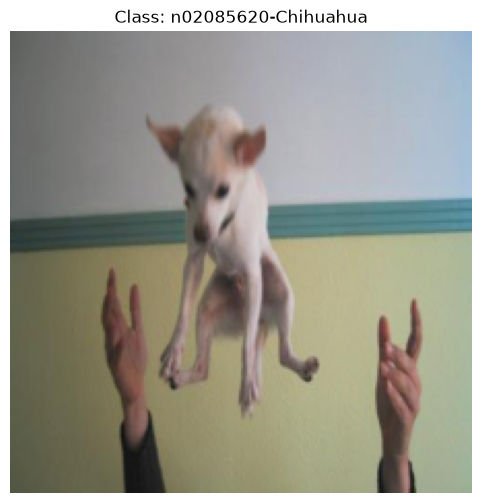

Label index: 0
Class name: n02085620-Chihuahua


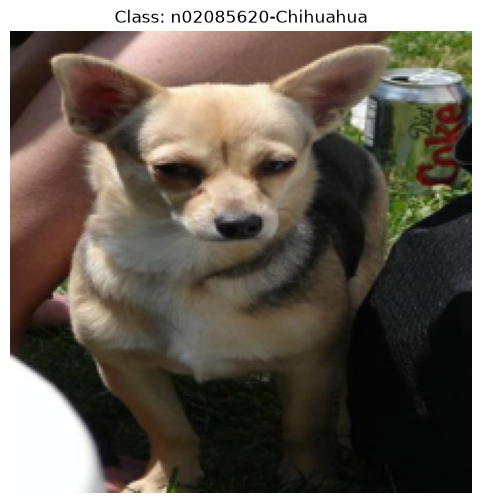

In [5]:
train_sample = train_dataset[0]
test_sample = valid_dataset[0]

visualize(train_sample)
visualize(test_sample)

### 물체의 위치 정보 확인

In [6]:
# Annotation 폴더에서 데이터 선택
annotation_path = os.path.join(annotation_dir, 'n02085620-Chihuahua/n02085620_7')

# XML 파일 파싱
tree = ET.parse(annotation_path)
root = tree.getroot()

for elem in root.iter():
    print(f"{elem.tag}: {elem.text}")

annotation: 
	
folder: 02085620
filename: n02085620_7
source: 
		
database: ImageNet database
size: 
		
width: 250
height: 188
depth: 3
segment: 0
object: 
		
name: Chihuahua
pose: Unspecified
truncated: 0
difficult: 0
bndbox: 
			
xmin: 71
ymin: 1
xmax: 192
ymax: 180


**Annotation 파일 구조**

```
annotation                 ← 최상위 루트
├── folder: 02085620       ← 클래스 폴더 원본 ID
├── filename: n02085620_7  ← 파일명
├── source
│   └── database: ImageNet database
├── size
│   ├── width: 250          ← 원본 이미지 가로 크기(px)
│   ├── height: 188         ← 원본 이미지 세로 크기(px)
│   └── depth: 3            ← 채널 수 (RGB=3)
├── segment: 0
└── object                  ← 이미지 안의 객체(강아지) 정보
    ├── name: Chihuahua     ← 클래스 이름
    ├── pose: Unspecified   ← 자세 정보 (보통 명시 안 됨)
    ├── truncated: 0        ← 객체가 이미지 경계에 잘렸는지 (0=아니오)
    ├── difficult: 0        ← 인식 난이도 플래그
    └── bndbox              ← 바운딩 박스 좌표
        ├── xmin: 71        ← 왼쪽 경계
        ├── ymin: 1         ← 상단 경계
        ├── xmax: 192       ← 오른쪽 경계
        └── ymax: 180       ← 하단 경계
```

## 3. ResNet50 모델 학습

In [8]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [10]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        print(f"\nEpoch {epoch+1}/{num_epochs} 시작")
        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            if (batch_idx + 1) % 100 == 0:
                print(f"  Step {batch_idx+1} - Loss: {loss.item():.4f}")

        train_loss = running_loss / (batch_idx + 1)
        train_acc = correct / total
        print(f"Train - Loss: {train_loss:.4f}, Accuracy: {train_acc*100:.2f}%")

        # 검증 단계
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        test_loss = running_loss / len(valid_loader)
        test_acc = correct / total
        print(f"Validation - Loss: {test_loss:.4f}, Accuracy: {test_acc*100:.2f}%")

In [12]:
%%time

train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=5)


Epoch 1/5 시작
  Step 100 - Loss: 3.3903
  Step 200 - Loss: 2.3003
  Step 300 - Loss: 3.6250
  Step 400 - Loss: 2.7139
  Step 500 - Loss: 2.6603
  Step 600 - Loss: 1.9785
  Step 700 - Loss: 2.7060
  Step 800 - Loss: 3.0980
  Step 900 - Loss: 2.1827
  Step 1000 - Loss: 2.2153
Train - Loss: 2.5261, Accuracy: 32.90%
Validation - Loss: 3.6084, Accuracy: 23.37%

Epoch 2/5 시작
  Step 100 - Loss: 1.5777
  Step 200 - Loss: 2.7288
  Step 300 - Loss: 1.6985
  Step 400 - Loss: 2.1225
  Step 500 - Loss: 1.5392
  Step 600 - Loss: 1.8147
  Step 700 - Loss: 1.9310
  Step 800 - Loss: 1.9012
  Step 900 - Loss: 1.8920
  Step 1000 - Loss: 2.3508
Train - Loss: 1.9604, Accuracy: 45.57%
Validation - Loss: 2.2214, Accuracy: 41.01%

Epoch 3/5 시작
  Step 100 - Loss: 1.6519
  Step 200 - Loss: 1.1535
  Step 300 - Loss: 1.6251
  Step 400 - Loss: 1.2843
  Step 500 - Loss: 2.0457
  Step 600 - Loss: 1.4727
  Step 700 - Loss: 1.3191
  Step 800 - Loss: 1.2354
  Step 900 - Loss: 2.2297
  Step 1000 - Loss: 0.6885
Train - L

In [13]:
# 학습된 모델 저장
cam_model_path = os.path.join('model', "cam_model.pt")

torch.save(model, cam_model_path)

## 4. CAM

In [7]:
def unnormalize(img_tensor):
    """
    img_tensor: [C, H, W] 텐서 (전처리 상태, 예: normalization 적용됨)
    ImageNet 평균 및 표준편차를 이용하여 복원 (RGB 순서)
    """
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    return img

In [39]:
# 원하는 데이터 선정
image, label, ground_bbox = train_dataset[10000]
sample_image = image.unsqueeze(0).to(device)

# 학습된 모델 불러오기
cam_model_path = os.path.join('model', "cam_model.pt")
model = torch.load(cam_model_path, weights_only=False)

In [9]:
def generate_cam(model, item):
    model.eval()
    features = []

    def forward_hook(module, input, output):
        """output만 받아서 features 리스트에 저장"""
        features.append(output.detach())
    forward_handle = model.layer4.register_forward_hook(forward_hook)

    try:
        # 순전파 실행
        output = model(item)   # layer4를 통과할 때 hook이 자동 실행됨
    finally:
        forward_handle.remove()

    pred_class = output.argmax(dim=1).item()  # 예측 클래스 선택
    fc_weights = model.fc.weight.data.to(item.device)   # fc layer의 가중치 행렬 가져옴

    fmap = features[0][0]   # shape: [C, H, W]
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=item.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]

    cam = cam.cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

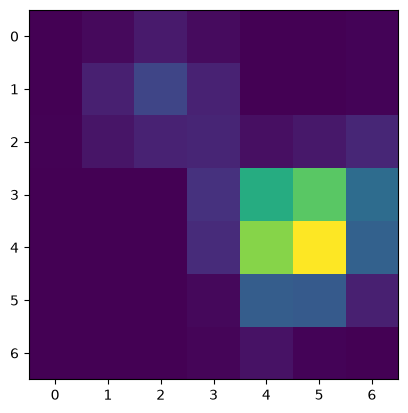

In [26]:
cam_image = generate_cam(model, sample_image)

plt.imshow(cam_image)

### CAM 시각화

In [63]:
def visualize_cam_on_image(cam, img, alpha=0.5, ax=None, title="CAM Overlay on Image"):
    """CAM과 원본 이미지 블렌딩 시각화"""
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = heatmap * alpha + img * (1 - alpha)
    overlay = overlay.astype(np.uint8)

    standalone = ax is None   # ax가 없으면 이 함수가 figure 생성부터 출력까지 담당
    if standalone:
        plt.figure(figsize=(8,8))
        ax = plt.gca()

    ax.imshow(overlay)
    ax.set_title(title)
    ax.axis('off')

    if standalone:
        plt.show()

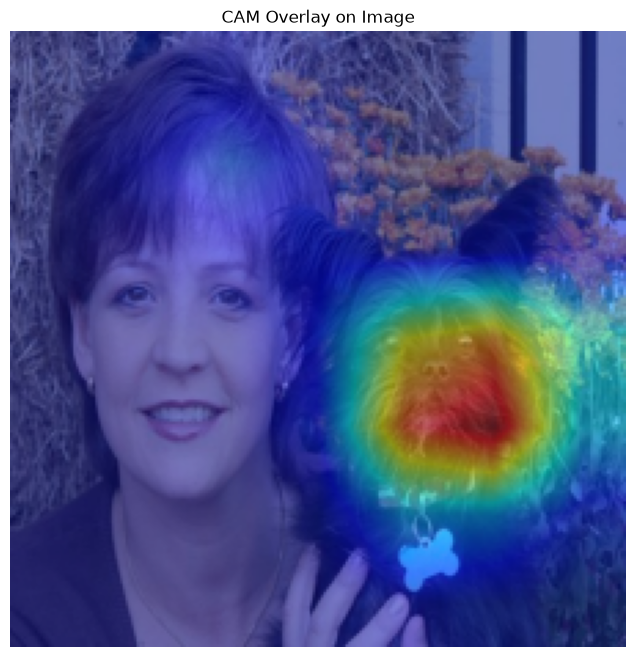

In [64]:
orig_img = unnormalize(image)
visualize_cam_on_image(cam_image, orig_img)

## 5. Grad_CAM

In [15]:
def generate_grad_cam(model, activation_layer, item):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient 저장
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    layer = dict(model.named_modules()).get(activation_layer, None)
    if layer is None:
        raise ValueError(f"{layer} is None")

    # hook 등록
    forward_handle = layer.register_forward_hook(forward_hook)
    backward_handle = layer.register_full_backward_hook(backward_hook)

    # forward 실행
    output = model(item)
    pred_class = output.argmax(dim=1).item()

    # backward 실행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출. shape: [C, H, W]
    fmap = features['value'][0]
    grads = gradients['value'][0]
    weights = torch.mean(grads, dim=(1, 2))   # cam의 fc 가중치의 역할을 gradient 평균이 대신

    # 각 채널의 feature map과 weight 가중합
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]

    grad_cam = grad_cam.cpu().numpy()
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam_image = (grad_cam - np.min(grad_cam)) / (np.max(grad_cam) - np.min(grad_cam) + 1e-8)

    return grad_cam_image

### 레이어별 Grad-CAM 비교

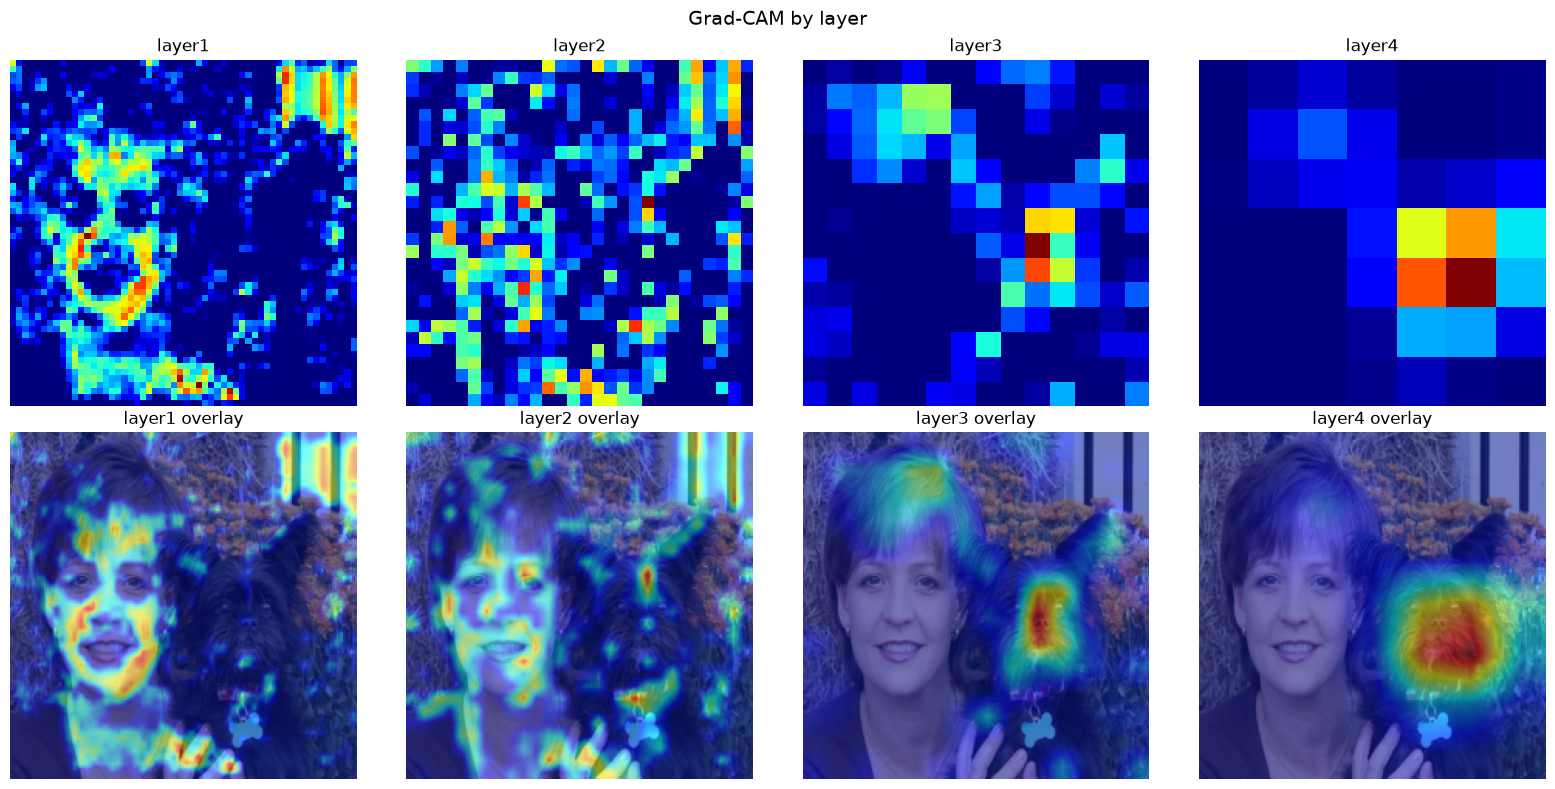

In [66]:
orig_img = unnormalize(image)

# layer1 ~ layer4 각각에 Grad-CAM 적용
target_layers = ['layer1', 'layer2', 'layer3', 'layer4']
layer_cams = {name: generate_grad_cam(model, name, sample_image) for name in target_layers}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, name in enumerate(target_layers):
    cam = layer_cams[name]

    # 윗줄: feature map 해상도의 Grad-CAM 히트맵
    axes[0, col].imshow(cam, cmap='jet')
    axes[0, col].set_title(f"{name}")
    axes[0, col].axis('off')

    # 아랫줄: 원본 이미지에 합성
    visualize_cam_on_image(cam, orig_img, ax=axes[1, col], title=f"{name} overlay")

fig.suptitle("Grad-CAM by layer", fontsize=14)
plt.tight_layout()
plt.show()

grad_cam_image = layer_cams['layer4']

- layer1 — 사람 얼굴 윤곽, 머리카락, 오른쪽 창틀 세로선에 골고루 반응.
- layer2 — 여전히 산발적이고, 사람 얼굴에 강하게 반응.
- layer3 — 강아지 얼굴이 최대 활성됨. 왼쪽 위 사람 머리카락에 약하게 반응이 남아 있움.
- layer4 — 강아지 얼굴만 강하게 반응.

## 6. 바운딩 박스 구하기

In [18]:
def get_bbox(cam, threshold=0.01):
    """바운딩 박스를 만들기 위해 threshold 이하의 영역 제외"""
    coords = np.argwhere(cam > threshold)
    if coords.size == 0:
        return None

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return (x_min, y_min, x_max, y_max)

In [75]:
cam_resized = cv2.resize(grad_cam_image, (orig_img.shape[1], orig_img.shape[0]))
bbox = get_bbox(cam_resized, threshold=0.2)

print(bbox)

(np.int64(78), np.int64(46), np.int64(223), np.int64(187))


In [76]:
def visualize_bbox_on_image(img, bbox, box_color=(255, 0, 0), thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), box_color, thickness)
    else:
        print("활성화된 영역이 없습니다.")
    return img_with_bbox

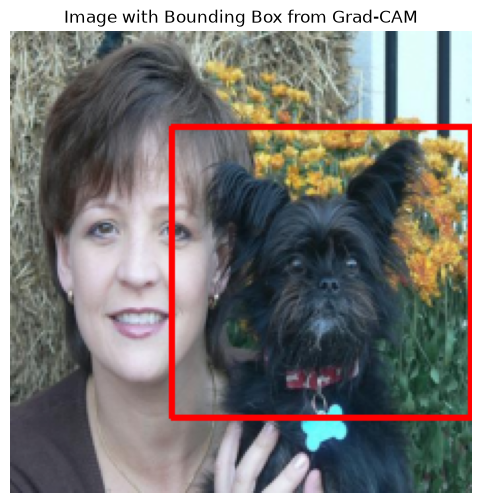

In [77]:
img_bbox = visualize_bbox_on_image(orig_img, bbox)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Image with Bounding Box from Grad-CAM")
plt.axis("off")
plt.show()

## 7. IoU 계산

In [35]:
def get_iou(bbox1, bbox2):
    """IoU를 계산하는 함수"""
    if bbox1 is None or bbox2 is None:
        return 0.0

    x_min1, y_min1, x_max1, y_max1 = bbox1
    x_min2, y_min2, x_max2, y_max2 = bbox2

    # 두 bbox의 교집합 영역 좌표 계산
    x_min_inter = max(x_min1, x_min2)
    y_min_inter = max(y_min1, y_min2)
    x_max_inter = min(x_max1, x_max2)
    y_max_inter = min(y_max1, y_max2)

    # 교집합의 너비와 높이 (음수가 되지 않도록)
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    inter_area = inter_width * inter_height

    # 각 bbox의 면적 계산
    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)

    # 합집합 면적
    union_area = area1 + area2 - inter_area
    if union_area <= 0:
        return 0.0

    iou = inter_area / union_area
    return iou

In [37]:
def visualize_both_bbox_on_image(img, bbox, ground_truth, thickness=2):
    """정답 바운딩 박스와 예측값 바운딩 박스 시각화"""
    # 원본 이미지 복사
    img_with_bbox = img.copy()

    x_min, y_min, x_max, y_max = bbox
    cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    x_min_t, y_min_t, x_max_t, y_max_t = ground_truth
    cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)

    return img_with_bbox

### CAM 바운딩 박스 vs 정답 바운딩 박스

In [52]:
cam_resized = cv2.resize(cam_image, (orig_img.shape[1], orig_img.shape[0]))
bbox = get_bbox(cam_resized, threshold=0.2)

print(bbox)
print(ground_bbox)
print('IoU: ', get_iou(bbox, ground_bbox))

(np.int64(78), np.int64(46), np.int64(223), np.int64(187))
[91.84, 50.77333333333334, 200.256, 223.40266666666668]
IoU:  0.605500713951094


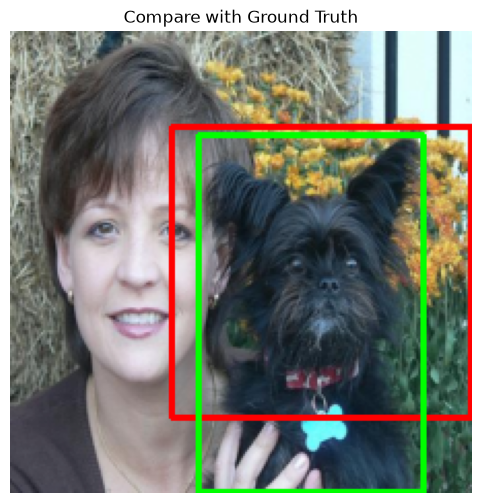

In [53]:
ground_truth = [int(x) for x in ground_bbox]

img_bbox = visualize_both_bbox_on_image(orig_img, bbox, ground_truth)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Compare with Ground Truth")
plt.axis("off")
plt.show()

### Grad-CAM 바운딩 박스 vs 정답 바운딩 박스

In [54]:
cam_resized = cv2.resize(grad_cam_image, (orig_img.shape[1], orig_img.shape[0]))
bbox = get_bbox(cam_resized, threshold=0.2)

print(bbox)
print(ground_bbox)
print('IoU: ', get_iou(bbox, ground_bbox))

(np.int64(78), np.int64(46), np.int64(223), np.int64(187))
[91.84, 50.77333333333334, 200.256, 223.40266666666668]
IoU:  0.605500713951094


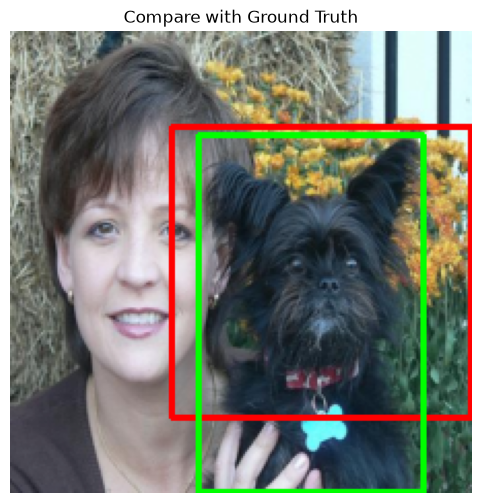

In [55]:
ground_truth = [int(x) for x in ground_bbox]

img_bbox = visualize_both_bbox_on_image(orig_img, bbox, ground_truth)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Compare with Ground Truth")
plt.axis("off")
plt.show()

### CAM과 Grad-CAM의 IoU가 동일한 이유

위 두 결과의 바운딩 박스와 IoU는 같다. 이는 **ResNet50처럼 `마지막 conv → GAP → FC` 로 끝나는 구조에서는 두 방법이 수학적으로 동일**하기 때문이다.

## 8. 다중 샘플 정량 평가

학습에 사용하지 않은 `valid_dataset` 에서 여러 장을 무작위로 뽑아 성능을 정량적으로 비교한다.

| 항목 | 설정 |
|---|---|
| 평가 데이터 | `valid_dataset` (test split) |
| 샘플 수 | 200장, 고정 시드(42)로 무작위 추출 |
| 비교 대상 | `CAM(layer4)`, `GradCAM(layer4)`, `GradCAM(layer3)` |
| 지표 | mean IoU, median IoU, IoU > 0.5 비율, pointing game 정확도 |

바운딩 박스를 만드는 `threshold`는 **방법마다 최적값이 다른 하이퍼파라미터**이므로 하나로 고정해 비교하면
특정 방법에 유리하게 기울어진다. 아래에서는 threshold를 방법별로 따로 정해 비교하고, threshold가 개입하지 않는 지표(pointing game)로 교차 검증한다.

In [81]:
import pandas as pd

METHODS = ['CAM(layer4)', 'GradCAM(layer4)', 'GradCAM(layer3)']

def collect_cams(model, dataset, indices, verbose_every=50):
    """샘플별로 세 가지 CAM을 계산하고 원본 크기로 resize해 캐시.

    threshold를 바꿔가며 여러 번 평가할 것이므로, CAM 계산은 한 번만 하고 결과를 재사용한다.
    """
    cache = []
    for n, idx in enumerate(indices, 1):
        img_tensor, label, gt = dataset[idx]

        # annotation이 없어 기본값 [0,0,0,0]이 들어간 샘플은 평가에서 제외
        if gt == [0.0, 0.0, 0.0, 0.0]:
            continue

        x = img_tensor.unsqueeze(0).to(device)
        h, w = img_tensor.shape[1], img_tensor.shape[2]

        # CAM은 순전파만 필요하므로 no_grad로 감싼다
        with torch.no_grad():
            cam_l4 = generate_cam(model, x)

        gcam_l4 = generate_grad_cam(model, 'layer4', x)
        gcam_l3 = generate_grad_cam(model, 'layer3', x)

        cache.append({
            'index': idx,
            'gt': gt,
            'CAM(layer4)':     cv2.resize(cam_l4,  (w, h)),
            'GradCAM(layer4)': cv2.resize(gcam_l4, (w, h)),
            'GradCAM(layer3)': cv2.resize(gcam_l3, (w, h)),
        })

        if n % verbose_every == 0:
            print(f"  {n}/{len(indices)} 처리 완료")

    return cache

In [82]:
def iou_table(cache, threshold=0.2, bbox_fn=get_bbox):
    """캐시된 CAM으로 샘플별 IoU 표를 만든다"""
    rows = []
    for item in cache:
        row = {'index': item['index']}
        for m in METHODS:
            row[m] = get_iou(bbox_fn(item[m], threshold), item['gt'])
        rows.append(row)
    return pd.DataFrame(rows)


def summarize(cache, thresholds_per_method):
    """방법별로 서로 다른 threshold를 적용해 성능을 집계한다.
        thresholds_per_method: {방법이름: threshold} 딕셔너리
    """
    rows = {}
    for m in METHODS:
        t = thresholds_per_method[m]
        s = iou_table(cache, threshold=t)[m]
        rows[m] = {
            'threshold':  t,
            'mean IoU':   s.mean(),
            'median IoU': s.median(),
            'IoU>0.5':    (s > 0.5).mean(),
        }
    return pd.DataFrame(rows).T


def pointing_game(cache, method):
    """CAM의 최대 활성 지점이 정답 박스 안에 들어가면 정답으로 센다."""
    hit = 0
    for item in cache:
        cam = item[method]
        y, x = np.unravel_index(np.argmax(cam), cam.shape)   # (행, 열) = (y, x)
        x_min, y_min, x_max, y_max = item['gt']
        if x_min <= x <= x_max and y_min <= y <= y_max:
            hit += 1
    return hit / len(cache)

In [83]:
%%time

# 평가 샘플 선정
NUM_SAMPLES = 200
rng = np.random.default_rng(42)
eval_indices = rng.choice(len(valid_dataset), size=NUM_SAMPLES, replace=False).tolist()

print(f"CAM 계산 시작 (총 {NUM_SAMPLES}개)")
cam_cache = collect_cams(model, valid_dataset, eval_indices)
print(f"\n평가에 사용된 유효 샘플 수: {len(cam_cache)}")

CAM 계산 시작 (총 200개)
  50/200 처리 완료
  100/200 처리 완료
  150/200 처리 완료
  200/200 처리 완료

평가에 사용된 유효 샘플 수: 200
CPU times: total: 2min 46s
Wall time: 59.9 s


In [84]:
# CAM(layer4)와 GradCAM(layer4)이 샘플 단위로도 동일한지 확인
iou_df = iou_table(cam_cache, threshold=0.2)

print("샘플별 IoU (상위 5개)")
display(iou_df.head())

diff = (iou_df['CAM(layer4)'] - iou_df['GradCAM(layer4)']).abs()
print(f"IoU 최대 차이   : {diff.max():.2e}")
print(f"일치하는 샘플 수: {(diff < 1e-9).sum()} / {len(diff)}")

# IoU뿐 아니라 히트맵 픽셀값 자체가 같은지도 확인
map_diff = max(np.abs(it['CAM(layer4)'] - it['GradCAM(layer4)']).max() for it in cam_cache)
print(f"히트맵 픽셀 최대 차이: {map_diff:.2e}")

샘플별 IoU (상위 5개)


,index,CAM(layer4),GradCAM(layer4),GradCAM(layer3)
0,3129,0.830909,0.830909,0.736669
1,4312,0.573533,0.573533,0.525186
2,3821,0.422540,0.422540,0.372211
3,8551,0.530788,0.530788,0.876243
4,770,0.379414,0.379414,0.627372


IoU 최대 차이   : 0.00e+00
일치하는 샘플 수: 200 / 200
히트맵 픽셀 최대 차이: 2.44e-06


### threshold에 따른 IoU 변화

`get_bbox`의 threshold는 바운딩 박스 크기를 직접 결정한다.
방법별로 최적값이 어디인지, 그리고 threshold 변화에 얼마나 민감한지 함께 확인한다.

,CAM(layer4),GradCAM(layer4),GradCAM(layer3)
threshold,,,
0.01,0.5889,0.5889,0.5586
0.03,0.6193,0.6193,0.5608
0.05,0.6164,0.6164,0.5635
0.08,0.5911,0.5911,0.5667
0.10,0.5726,0.5726,0.5692
0.20,0.4741,0.4741,0.5840
0.30,0.3829,0.3829,0.5786
0.40,0.3060,0.3060,0.5292
0.50,0.2399,0.2399,0.4537


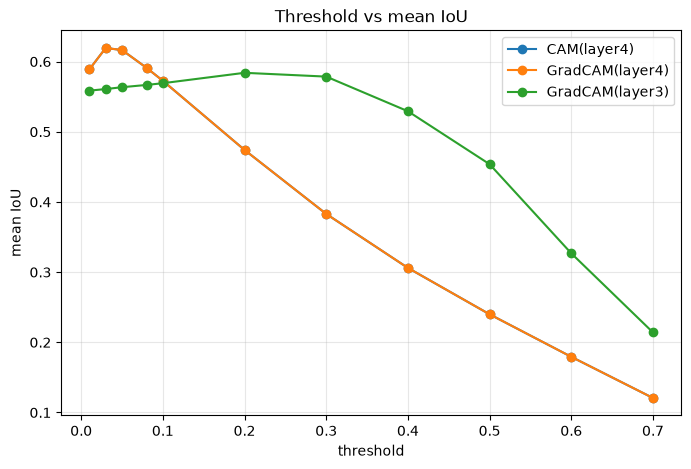

방법별 최고 지점
  CAM(layer4)        threshold=0.03  mean IoU=0.6193
  GradCAM(layer4)    threshold=0.03  mean IoU=0.6193
  GradCAM(layer3)    threshold=0.2   mean IoU=0.5840


In [96]:
thresholds = [0.01, 0.03, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

sweep_rows = []
for t in thresholds:
    means = iou_table(cam_cache, threshold=t)[METHODS].mean()
    means['threshold'] = t
    sweep_rows.append(means)

sweep_df = pd.DataFrame(sweep_rows).set_index('threshold')
display(sweep_df.round(4))

plt.figure(figsize=(8, 5))
for col in METHODS:
    plt.plot(sweep_df.index, sweep_df[col], marker='o', label=col)
plt.xlabel('threshold')
plt.ylabel('mean IoU')
plt.title('Threshold vs mean IoU')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 방법별 정점 위치
print("방법별 최고 지점")
for m in METHODS:
    t = sweep_df[m].idxmax()
    print(f"  {m:18s} threshold={t:<5} mean IoU={sweep_df.loc[t, m]:.4f}")

### 방법별 최적 threshold에서의 비교

threshold는 방법마다 최적값이 다르므로 각자의 최적값에서 비교해야 한다.

In [86]:
half = len(cam_cache) // 2
tune_cache, test_cache = cam_cache[:half], cam_cache[half:]
print(f"튜닝셋 {len(tune_cache)}장 / 평가셋 {len(test_cache)}장")

# 튜닝셋에서 방법별 최적 threshold 선택
best_thresholds = {}
for m in METHODS:
    scores = {t: iou_table(tune_cache, threshold=t)[m].mean() for t in thresholds}
    best_thresholds[m] = max(scores, key=scores.get)

print("\n튜닝셋에서 고른 threshold:", best_thresholds)

# 각자의 threshold로 평가셋에서 측정
print("\n=== 방법별 최적 threshold에서의 평가셋 성능 ===")
display(summarize(test_cache, best_thresholds).round(4))

# 튜닝셋 대비 얼마나 부풀려졌는지 확인
print("=== 과적합 폭 (튜닝셋 - 평가셋) ===")
for m in METHODS:
    t = best_thresholds[m]
    tune_s = iou_table(tune_cache, threshold=t)[m].mean()
    test_s = iou_table(test_cache, threshold=t)[m].mean()
    print(f"  {m:18s} t={t:<5} tune={tune_s:.4f}  test={test_s:.4f}  차이={tune_s - test_s:+.4f}")

튜닝셋 100장 / 평가셋 100장

튜닝셋에서 고른 threshold: {'CAM(layer4)': 0.03, 'GradCAM(layer4)': 0.03, 'GradCAM(layer3)': 0.2}

=== 방법별 최적 threshold에서의 평가셋 성능 ===


,threshold,mean IoU,median IoU,IoU>0.5
CAM(layer4),0.03,0.6347,0.6844,0.73
GradCAM(layer4),0.03,0.6347,0.6844,0.73
GradCAM(layer3),0.20,0.6055,0.6775,0.70


=== 과적합 폭 (튜닝셋 - 평가셋) ===
  CAM(layer4)        t=0.03  tune=0.6040  test=0.6347  차이=-0.0307
  GradCAM(layer4)    t=0.03  tune=0.6040  test=0.6347  차이=-0.0307
  GradCAM(layer3)    t=0.2   tune=0.5625  test=0.6055  차이=-0.0430


### threshold와 무관한 지표: pointing game

IoU에는 CAM 자체의 품질과 threshold 선택이 뒤섞여 있다.
**pointing game**은 CAM의 최대 활성 지점이 정답 박스 안에 있는지만 확인하므로 threshold가 개입하지 않는다. **"물체를 제대로 가리키는가"** 를 재는 지표다.

In [88]:
pg = pd.Series({m: pointing_game(cam_cache, m) for m in METHODS},
               name='pointing game acc')

print(f"=== pointing game 정확도 (n={len(cam_cache)}) ===")
display(pg.round(4).to_frame())

=== pointing game 정확도 (n=200) ===


,pointing game acc
CAM(layer4),0.96
GradCAM(layer4),0.96
GradCAM(layer3),0.92


### IoU 분포 확인

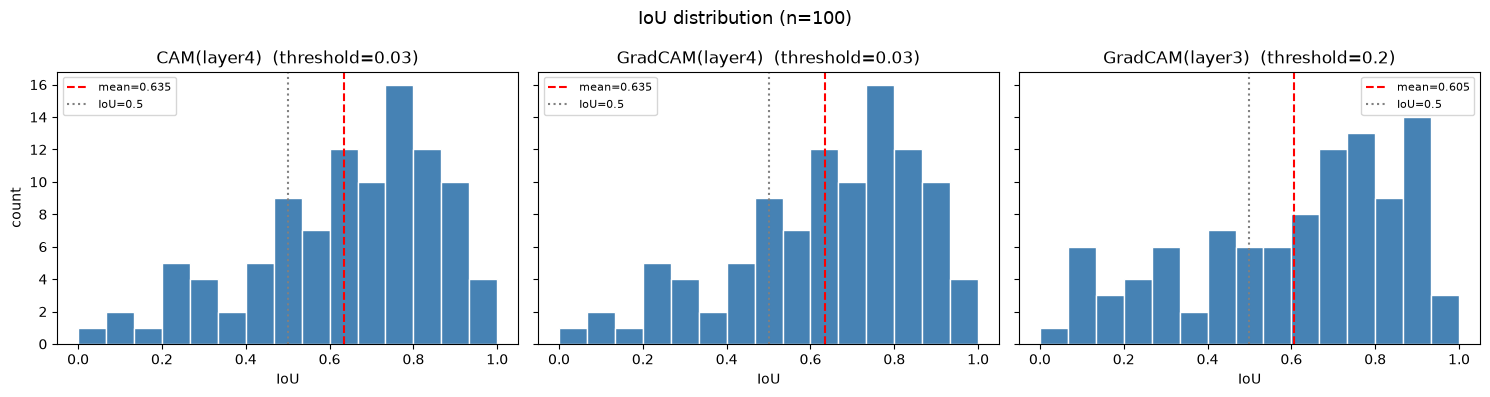

In [90]:
fig, axes = plt.subplots(1, len(METHODS), figsize=(15, 4), sharey=True)
for ax, m in zip(axes, METHODS):
    t = best_thresholds[m]
    s = iou_table(test_cache, threshold=t)[m]

    ax.hist(s, bins=15, range=(0, 1), color='steelblue', edgecolor='white')
    ax.axvline(s.mean(), color='red', linestyle='--', label=f"mean={s.mean():.3f}")
    ax.axvline(0.5, color='gray', linestyle=':', label='IoU=0.5')
    ax.set_title(f"{m}  (threshold={t})")
    ax.set_xlabel('IoU')
    ax.legend(fontsize=8)

axes[0].set_ylabel('count')
fig.suptitle(f"IoU distribution (n={len(test_cache)})", fontsize=13)
plt.tight_layout()
plt.show()

## 9. 박스 추출 알고리즘 개선

섹션 8에서 pointing game 정확도는 0.92 ~ 0.96인데 IoU는 0.60 ~ 0.63에 그쳤다. CAM은 물체를 제대로 가리키고 있으므로 **병목은 히트맵을 박스로 옮기는 과정**에 있다.

기존 `get_bbox`는 threshold를 넘는 모든 픽셀의 전역 min/max로 박스를 만든다.
그래서 객체와 떨어진 곳에 활성값이 하나라도 튀면 박스가 통째로 늘어난다. 이를 개선한 세 가지 방식을 기존 방식과 비교한다.

| 방식 | 아이디어 |
|---|---|
| `get_bbox` (기준선) | threshold를 넘는 모든 픽셀의 min/max |
| `largest component` | 가장 큰 연결 성분만 사용 — 떨어진 잡음 제거 |
| `contour` | 가장 면적이 큰 외곽선의 bounding rect — 위와 같은 아이디어, 더 빠름 |
| `percentile` | 고정값 대신 분위수로 threshold를 정해 이미지마다 자동 적응 |

In [97]:
def get_bbox_largest(cam, threshold=0.2):
    """threshold를 넘는 영역 중 가장 큰 연결 성분만으로 박스를 만든다"""
    mask = (cam > threshold).astype(np.uint8)
    if mask.sum() == 0:
        return None

    n_labels, labels = cv2.connectedComponents(mask)
    if n_labels <= 1:          # 배경만 존재
        return None

    # 배경을 제외하고 픽셀 수가 가장 많은 성분 선택
    areas = [(labels == i).sum() for i in range(1, n_labels)]
    largest = int(np.argmax(areas)) + 1

    coords = np.argwhere(labels == largest)   # (y, x) 순서
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return (x_min, y_min, x_max, y_max)

In [100]:
def get_bbox_contour(cam, threshold=0.2):
    """가장 면적이 큰 외곽선의 bounding rect"""
    mask = (cam > threshold).astype(np.uint8)
    if mask.sum() == 0:
        return None

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    return (x, y, x + w, y + h)

In [102]:
def get_bbox_percentile(cam, threshold=0.9):
    """고정값 대신 CAM의 상위 (1-threshold) 비율만 남긴다.
    threshold=0.9면 상위 10% 픽셀을 사용한다. 이미지마다 활성 분포가 달라도 자동으로 적응한다.
    """
    cutoff = np.percentile(cam, threshold * 100)
    return get_bbox(cam, cutoff)

### bbox_fn별 threshold 그리드

`percentile` 계열은 threshold의 **의미가 다르다.**
기존 방식은 활성값(0~1)이지만 퍼센타일은 분위수라서, 기존 그리드(0.01~0.7)를 그대로 쓰면
"하위 1%~70% 제외" 가 되어 박스가 이미지 전체가 된다.
따라서 방식마다 탐색 범위를 따로 정의한다.

In [103]:
ACT_GRID = [0.01, 0.03, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]   # 활성값 기준
PCT_GRID = [0.70, 0.80, 0.85, 0.90, 0.95, 0.98]                # 분위수 기준

BBOX_FNS = {
    'get_bbox (기준선)':    (get_bbox,                  ACT_GRID),
    'largest component':    (get_bbox_largest,          ACT_GRID),
    'contour':              (get_bbox_contour,          ACT_GRID),
    'percentile':           (get_bbox_percentile,       PCT_GRID),
}

for name, (fn, grid) in BBOX_FNS.items():
    print(f"  {name:22s} threshold 후보 {len(grid)}개  {grid}")

  get_bbox (기준선)         threshold 후보 9개  [0.01, 0.03, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]
  largest component      threshold 후보 9개  [0.01, 0.03, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]
  contour                threshold 후보 9개  [0.01, 0.03, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]
  percentile             threshold 후보 6개  [0.7, 0.8, 0.85, 0.9, 0.95, 0.98]


### 개선 전후 비교

섹션 8과 동일하게 **튜닝셋에서 threshold를 고르고 평가셋에서 측정**한다.

In [104]:
%%time

rows = []
best_by_fn = {}

for fn_name, (fn, grid) in BBOX_FNS.items():
    # (fn, threshold)마다 한 번만 계산하고 세 방법 컬럼을 모두 읽는다
    tune_scores = {t: iou_table(tune_cache, threshold=t, bbox_fn=fn) for t in grid}
    best_by_fn[fn_name] = {}

    for m in METHODS:
        best_t = max(grid, key=lambda t: tune_scores[t][m].mean())
        best_by_fn[fn_name][m] = best_t

        s = iou_table(test_cache, threshold=best_t, bbox_fn=fn)[m]
        rows.append({
            'bbox_fn':   fn_name,
            'method':    m,
            'threshold': best_t,
            'mean IoU':  round(s.mean(), 4),
            'IoU>0.5':   round((s > 0.5).mean(), 4),
        })

compare_df = pd.DataFrame(rows)

print("=== 박스 추출 방식별 mean IoU ===")
pivot = compare_df.pivot(index='bbox_fn', columns='method', values='mean IoU')
pivot = pivot.loc[list(BBOX_FNS), METHODS]   # 행/열 순서를 정의 순서로 고정
display(pivot)

print("=== 기준선 대비 개선폭 ===")
display((pivot - pivot.loc['get_bbox (기준선)']).round(4))

=== 박스 추출 방식별 mean IoU ===


method,CAM(layer4),GradCAM(layer4),GradCAM(layer3)
bbox_fn,,,
get_bbox (기준선),0.6347,0.6347,0.6055
largest component,0.6320,0.6320,0.5608
contour,0.6281,0.6281,0.5577
percentile,0.5278,0.5278,0.5920


=== 기준선 대비 개선폭 ===


method,CAM(layer4),GradCAM(layer4),GradCAM(layer3)
bbox_fn,,,
get_bbox (기준선),0.0000,0.0000,0.0000
largest component,-0.0027,-0.0027,-0.0447
contour,-0.0066,-0.0066,-0.0478
percentile,-0.1069,-0.1069,-0.0135


CPU times: total: 17.1 s
Wall time: 8.12 s


### 방식별 상세 (선택된 threshold와 IoU > 0.5 비율)

In [105]:
display(compare_df.set_index(['bbox_fn', 'method']))

threshold  mean IoU  IoU>0.5
bbox_fn           method                                       
get_bbox (기준선)    CAM(layer4)           0.03    0.6347     0.73
                  GradCAM(layer4)       0.03    0.6347     0.73
                  GradCAM(layer3)       0.20    0.6055     0.70
largest component CAM(layer4)           0.03    0.6320     0.73
                  GradCAM(layer4)       0.03    0.6320     0.73
                  GradCAM(layer3)       0.01    0.5608     0.57
contour           CAM(layer4)           0.03    0.6281     0.73
                  GradCAM(layer4)       0.03    0.6281     0.73
                  GradCAM(layer3)       0.01    0.5577     0.57
percentile        CAM(layer4)           0.70    0.5278     0.58
                  GradCAM(layer4)       0.70    0.5278     0.58
                  GradCAM(layer3)       0.85    0.5920     0.70

### 개선 전후 시각화

개선 폭이 큰 샘플을 골라 기준선 박스와 개선된 박스를 함께 그린다.

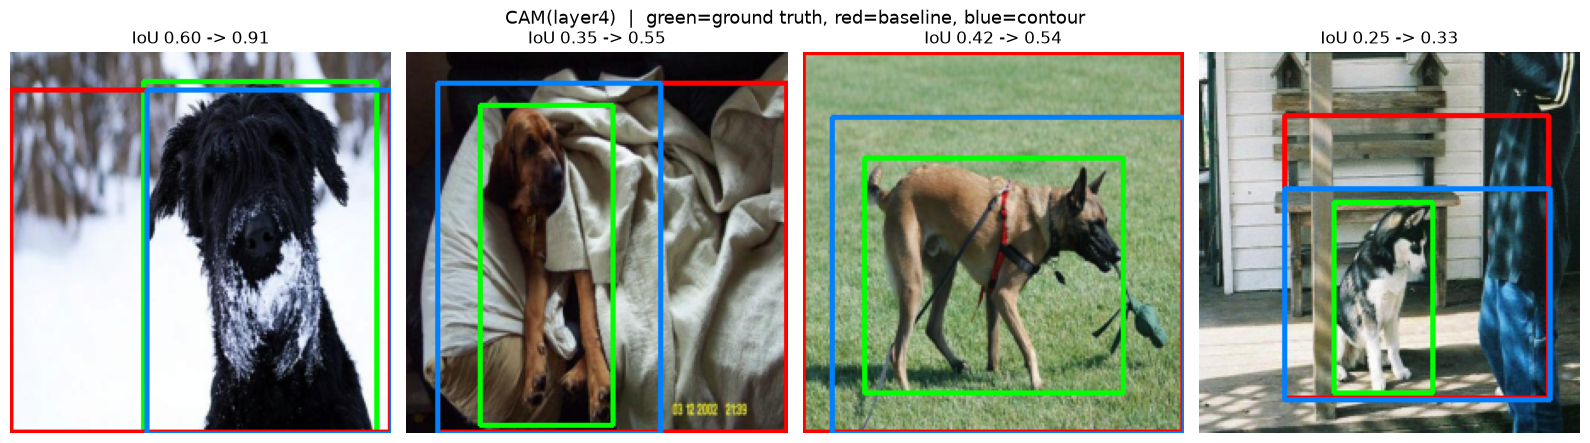

In [106]:
M_VIS    = 'CAM(layer4)'            # 시각화에 사용할 방법
FN_BASE  = 'get_bbox (기준선)'
FN_IMP   = 'contour'                # 비교할 개선 방식

fn_base, _ = BBOX_FNS[FN_BASE]
fn_imp,  _ = BBOX_FNS[FN_IMP]
t_base = best_by_fn[FN_BASE][M_VIS]
t_imp  = best_by_fn[FN_IMP][M_VIS]

iou_base = iou_table(test_cache, threshold=t_base, bbox_fn=fn_base)[M_VIS]
iou_imp  = iou_table(test_cache, threshold=t_imp,  bbox_fn=fn_imp)[M_VIS]

# 개선 폭이 큰 상위 4개 샘플
top = (iou_imp - iou_base).sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, pos in zip(axes, top):
    item = test_cache[pos]
    vis = unnormalize(valid_dataset[item['index']][0]).copy()

    gt = [int(v) for v in item['gt']]
    cv2.rectangle(vis, (gt[0], gt[1]), (gt[2], gt[3]), (0, 255, 0), 2)          # 정답: 초록

    for box, color in [(fn_base(item[M_VIS], t_base), (255, 0, 0)),             # 개선 전: 빨강
                       (fn_imp(item[M_VIS],  t_imp),  (0, 128, 255))]:          # 개선 후: 파랑
        if box is not None:
            x1, y1, x2, y2 = (int(v) for v in box)
            cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)

    ax.imshow(vis)
    ax.axis('off')
    ax.set_title(f"IoU {iou_base[pos]:.2f} -> {iou_imp[pos]:.2f}")

fig.suptitle(f"{M_VIS}  |  green=ground truth, red=baseline, blue={FN_IMP}", fontsize=13)
plt.tight_layout()
plt.show()

## 10. 결과 분석

### 1. CAM과 Grad-CAM은 동일하다

- 200장 전체에서 두 방법의 IoU가 완전히 일치
- 히트맵 픽셀값 최대 차이 `2.44e-06`


ResNet50은 `마지막 conv → GAP → FC` 구조이므로 Grad-CAM의 채널 가중치가 CAM의 FC 가중치와 상수배 관계가 되고, ReLU와 정규화를 거치면 그 상수배가 상쇄되어 완전히 같은 맵이 된다. 

따라서 이 구조에서 두 방법의 localization 성능을 비교하는 것은 의미가 없다.
Grad-CAM의 가치는 성능이 아니라 CAM이 구조적으로 접근할 수 없는 중간 레이어에도 적용된다는 점이다.

### 2. threshold별 세 방법 비교

| 비교 방식 | CAM / Grad-CAM(layer4) | Grad-CAM(layer3) |
|---|---|---|
| threshold 0.2로 고정 | 0.4741 | **0.5840** |
| 각자의 최적 threshold | **0.6347** (t=0.03) | 0.6055 (t=0.2) |

- 최적 threshold: layer4 = **0.03**, layer3 = **0.2**
- threshold 0.01 ~ 0.3 구간의 변동폭: layer4 0.3829 ~ 0.6193 / layer3 0.5586 ~ 0.5840
- 평가셋 성능: layer4 mean 0.6347 · median 0.6844 · IoU>0.5 **0.73**
  / layer3 mean 0.6055 · median 0.6775 · IoU>0.5 **0.70**
- 튜닝셋과 평가셋의 점수 차이: 0.031 ~ 0.043


**threshold를 고정하면 순위가 바뀐다.** 0.2는 layer3의 최적값이면서 layer4에게는 크게 벗어난값이라, 0.2 고정에서는 layer3이 0.11 앞서지만 각자의 최적값에서 재면 layer4가 앞선다. 
threshold는 성능에 중요한 하이퍼파라미터이다.

**최적값이 다른 이유는 feature map 해상도다.** layer4는 7×7을 224×224로 32배 확대하므로 활성이 뾰족하게 몰려 있어 객체를 덮으려면 threshold를 0.03까지 낮춰야 한다.
layer3은 14×14를 16배 확대해 활성이 더 고르게 퍼지므로 0.2에서 성능이 가장 좋다.

**다만 방법 간 성능 차이 자체는 작다.** 평가셋 격차는 0.029인데, 같은 threshold를 적용한 튜닝셋과 평가셋의 점수 차이가 
0.031 ~ 0.043으로 그보다 크다. 최적 threshold에서 그린 IoU 분포 역시 셋 다 0.6~0.95에 몰린 비슷한 형태다. 세 방법은 거의 비슷한 성능이다.

### 3. pointing game

- pointing game 정확도: layer4 **0.96** / layer3 **0.92** (n=200)
- 같은 CAM으로 만든 박스의 IoU는 0.60~0.63

두 방법 모두 거의 항상 강아지를 정확히 가리키는데, 박스로 옮기면 IoU가 0.6대로 떨어진다.
실패 원인은 "엉뚱한 곳을 본다"가 아니라 **"본 곳을 박스로 옮기는 과정이 부정확하다"** 는 의미이다.
저해상도 맵을 확대해 단순 threshold로 잘라내는 `get_bbox` 방식의 한계이며, 성능을 더 끌어올리려면 CAM 자체보다 **박스 추출 알고리즘**을 개선해야 한다.


### 종합 결론

- **CAM ≡ Grad-CAM(layer4)**: ResNet50에서 두 방법은 수학적으로 동치이다. Grad-CAM은 중간 레이어에도 적용된다는 장점이 있다.
- **세 방법의 localization 성능은 대등하다**: 각자의 최적 threshold에서 mean IoU 0.60 ~ 0.63, IoU > 0.5 비율 0.70 ~ 0.73.
- **남은 한계는 박스 추출이다**: pointing game 0.92 ~ 0.96이 보여주듯 객체 인식 자체는 잘 수행되었다. 개선 여지는 CAM이 아니라 박스를 뽑는 단계이다.

### 회고

CAM과 Grad-CAM을 다시 공부하는 계기가 되었고, 두 방법의 차이도 명확히 이해할 수 있었다. 특히 ResNet50처럼 GAP과 FC로 끝나는 구조에서는 두 방법이 수학적으로 동치라는 점, 그래서 Grad-CAM의 강점은 성능이 아니라 중간 레이어에도 적용할 수 있는 범용성에 있다는 점이 더 확실히 알 수 있었다.

IoU 0.5 이상이면 정답으로 치기에 기준이 너무 후한 것 아닌가 생각했는데, 직접 계산해 보니 threshold를 최적값으로 맞추고도 열 장 중 세 장은 0.5를 넘기지 못했다. 생각만큼 쉬운 기준이 아니였다.

결과를 분석하면서 문제가 CAM의 성능이 아니라 박스 추출 방식에 있다는 것도 알게 되었다. pointing game 정확도는 0.92 ~ 0.96으로 물체는 거의 정확히 가리키는데, 그것을 박스로 옮기는 순간 IoU가 0.6대로 떨어졌기 때문이다.
앞으로 박스 추출 알고리즘을 개선한 뒤 ACoL까지 구현해 볼 계획이다.